# Custome Reward Trials - R1 + R2 - Cart Position + Pole Angle

Episode 50	Average Reward: 44.24
Episode 100	Average Reward: 97.86
Episode 150	Average Reward: 180.38
Episode 200	Average Reward: 200.00

Environment solved in 228 episodes with average reward 195.19 over the last 100.00 episodes.


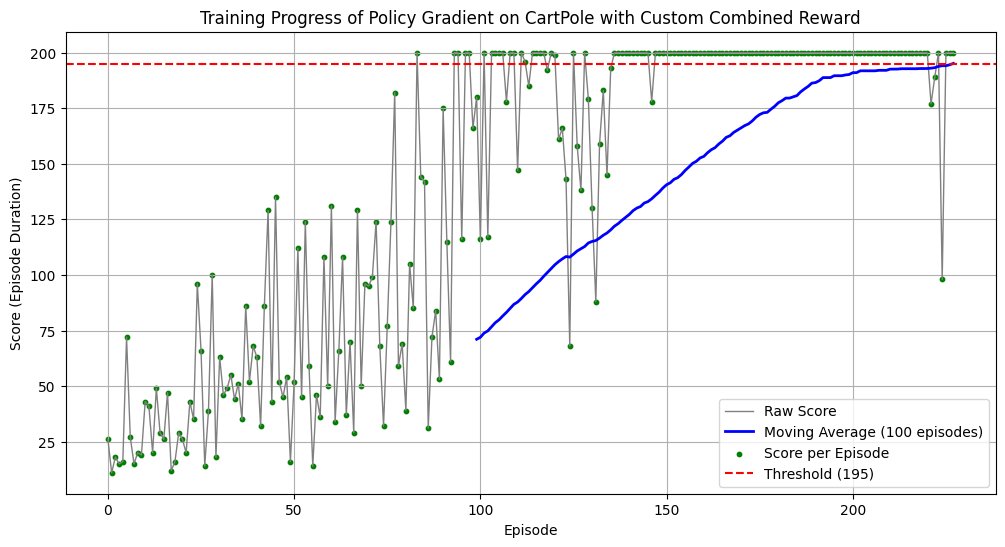

/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

Test Scores Summary:
count    100.000000
mean     183.780000
std       29.479519
min       43.000000
25%      176.000000
50%      200.000000
75%      200.000000
max      200.000000
Name: Score, dtype: float64
Success Count (Score >= 195):
Success
True     66
False    34
Name: count, dtype: int64


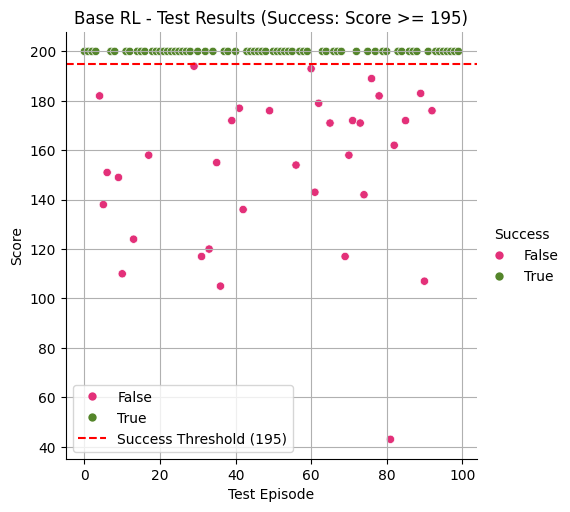

In [ ]:
# Import necessary libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gym, random
import matplotlib.pyplot as plt

# Set the random seed for reproducibility
seed = 20
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Create the environment
env = gym.make('CartPole-v0')
env.seed(seed)

# Get state and action dimensions
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# Get thresholds from environment constraints
theta_threshold = (env.observation_space.high[2]) / 2 - 0.001  # Pole angle
x_threshold = env.observation_space.high[0]  # Cart position

# Define the policy network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        probs = self.softmax(x)
        return probs

# Instantiate the policy network
policy_net = PolicyNetwork(state_dim, action_dim, hidden_size=128)

# Set the optimizer
learning_rate = 0.003
optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)

# Training parameters
gamma = 0.95
num_episodes = 500
max_steps = 500

# For logging
episode_rewards = []

for episode in range(1, num_episodes + 1):
    env.seed(episode)
    state = env.reset()
    env.seed(episode)

    state = torch.from_numpy(state).float()
    rewards = []
    log_probs = []

    for t in range(max_steps):
        # Get action probabilities from the policy network
        probs = policy_net(state)
        # Sample an action from the probability distribution
        m = torch.distributions.Categorical(probs)
        action = m.sample()
        log_prob = m.log_prob(action)
        # Step the environment
        next_state, _, done, _ = env.step(action.item())

        # Extract state variables
        x = abs(next_state[0])  # Cart position (absolute value)
        theta = abs(next_state[2])  # Pole angle (absolute value)

        # Compute custom rewards
        cart = np.exp((x_threshold - x) / x_threshold) - 0.8  # Cart position reward
        angle = np.exp((theta_threshold - theta) / theta_threshold) - 0.5  # Pole angle reward
        reward = (1 * cart) + (1 * angle)  # Combined reward

        next_state = torch.from_numpy(next_state).float()
        # Save reward and log probability
        rewards.append(reward)
        log_probs.append(log_prob)
        # Update state
        state = next_state
        if done:
            break

    # Compute the cumulative rewards (returns) for the episode
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns)
    # Normalize returns for better convergence
    returns = (returns - returns.mean()) / (returns.std() + 1e-9)
    # Compute policy gradient loss
    loss = []
    for log_prob, Gt in zip(log_probs, returns):
        loss.append(-log_prob * Gt)
    loss = torch.stack(loss).sum()
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Log episode reward
    episode_rewards.append(t + 1)
    # Print progress every 50 episodes
    if episode % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode}\tAverage Reward: {avg_reward:.2f}")

    convergence_criteria = 100
    # Check for convergence
    if episode >= convergence_criteria:
        avg_reward = np.mean(episode_rewards[-convergence_criteria:])
        if avg_reward >= 195.0:
            print(f"\nEnvironment solved in {episode} episodes with average reward {avg_reward:.2f} over the last {convergence_criteria:.2f} episodes.")
            break

# Close the environment
env.close()

# Convert 'episode_rewards' to a NumPy array for easy manipulation
score_array = np.array(episode_rewards)

# Calculate a moving average with a window size of 50
window_size = 100
if len(score_array) >= window_size:
    moving_avg = np.convolve(score_array, np.ones(window_size) / window_size, mode='valid')
else:
    moving_avg = score_array  # If not enough data points, use the raw scores

# Plot the raw scores and the moving average
plt.figure(figsize=(12, 6))
plt.plot(score_array, color='gray', linewidth=1, label='Raw Score')
plt.plot(range(window_size - 1, len(score_array)), moving_avg, color='blue', linewidth=2, label=f'Moving Average ({window_size} episodes)')
plt.scatter(range(len(score_array)), score_array, color='green', s=10, label='Score per Episode')
plt.axhline(y=195, color='red', linestyle='--', label='Threshold (195)')

# Labels and title
plt.xlabel('Episode')
plt.ylabel('Score (Episode Duration)')
plt.title('Training Progress of Policy Gradient on CartPole with Custom Combined Reward')
plt.legend()
plt.grid(True)
plt.show()


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Function to sample action based on the trained policy
def test_policy_sample(state, policy_net):
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        action_probs = policy_net(state_tensor)
        dist = torch.distributions.Categorical(action_probs)
        action = dist.sample().item()
    return action

# Function to test the agent's performance in one episode
def test_agent_base_rl(seed, print_reward=False):
    env = gym.make('CartPole-v0')
    env.seed(seed)
    state = env.reset()
    env.seed(seed)

    rewards = []

    for t in range(200):
        action = test_policy_sample(state, policy_net)
        state, reward, terminated, truncated = env.step(action)
        done = terminated or truncated
        rewards.append(reward)
        if done:
            total_reward = sum(rewards)
            if print_reward:
                print(f"Episode {seed}, Total Reward: {total_reward}")
            return total_reward
    env.close()

# Function to test the agent across multiple episodes and visualize the results
def plot_test_results_base_rl(method='Base RL', total_tests=100):
    test_scores = []
    for i in range(total_tests):
        test_scores.append(test_agent_base_rl(i, print_reward=False))

    # Print summary statistics
    print("Test Scores Summary:")
    test_df = pd.DataFrame({'Test': range(total_tests), 'Score': test_scores})
    test_df['Success'] = test_df['Score'] >= 195
    print(test_df['Score'].describe())

    # Count successes
    success_count = test_df['Success'].value_counts()
    print("Success Count (Score >= 195):")
    print(success_count)

    # Visualization
    colors = {True: "#54852A", False: "#E33079"}
    sns.relplot(data=test_df, x="Test", y="Score", hue="Success", palette=colors)
    plt.axhline(y=195, color='red', linestyle='--', label='Success Threshold (195)')
    plt.title(f"{method} - Test Results (Success: Score >= 195)")
    plt.xlabel("Test Episode")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the testing and plotting function
plot_test_results_base_rl(method="Base RL", total_tests=100)

In [ ]:
# Save the trained model
model_save_path = "/content/policy_net.pth"  # Adjust path as needed
torch.save(policy_net.state_dict(), model_save_path)

print(f"Model saved to {model_save_path}")

Model saved to /content/policy_net.pth


In [ ]:
from google.colab import files

# Download the saved model
files.download(model_save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install onnx
!pip install onnxruntime
!pip install torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.6 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn

# Define the PolicyNetwork class
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        probs = self.softmax(x)
        return probs

# Recreate the model structure
state_dim = 4  # State space dimension for CartPole-v0
action_dim = 2  # Action space dimension for CartPole-v0
policy_net = PolicyNetwork(state_dim, action_dim)

# Load the model weights
model_path = "/content/policy_net.pth"  # Update the path as needed
policy_net.load_state_dict(torch.load(model_path))
policy_net.eval()  # Set the model to evaluation mode

print("Model loaded successfully!")


Model loaded successfully!


<ipython-input-5-412887b028a7>:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  policy_net.load_state_dict(torch.load(model_path))


In [ ]:
import torch.onnx

# Create a dummy input tensor (matching the state_dim of CartPole)
dummy_input = torch.randn(1, state_dim)

# Export the model to ONNX
onnx_file_path = "/content/CartPole.onnx"
torch.onnx.export(
    policy_net,
    dummy_input,
    onnx_file_path,
    opset_version=11,  # ONNX opset version
    input_names=["input"],  # Input tensor name
    output_names=["output"],  # Output tensor name
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}}  # Support dynamic batch sizes
)

print(f"Model exported to ONNX format at: {onnx_file_path}")


Model exported to ONNX format at: /content/CartPole.onnx


In [ ]:
import onnx
import onnxruntime as ort
import numpy as np

# Load the ONNX model
onnx_model_path = "/content/CartPole.onnx"
onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)  # Validate the ONNX model
print("ONNX model is valid!")

# Perform inference with ONNX Runtime
ort_session = ort.InferenceSession(onnx_model_path)

# Create a test input tensor (similar to dummy_input)
test_input = np.random.randn(1, state_dim).astype(np.float32)

# Run the ONNX model
outputs = ort_session.run(None, {"input": test_input})

print(f"ONNX Inference Output: {outputs}")


ONNX model is valid!
ONNX Inference Output: [array([[9.9998915e-01, 1.0905814e-05]], dtype=float32)]


In [ ]:
from google.colab import files

# Download the ONNX file to your local machine
onnx_file_path = "/content/CartPole.onnx"
files.download(onnx_file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# PPO with custom reward

Episode 50, Average Reward: 90.98

Environment solved in 87 episodes with average reward 195.96 over the last 50 episodes.


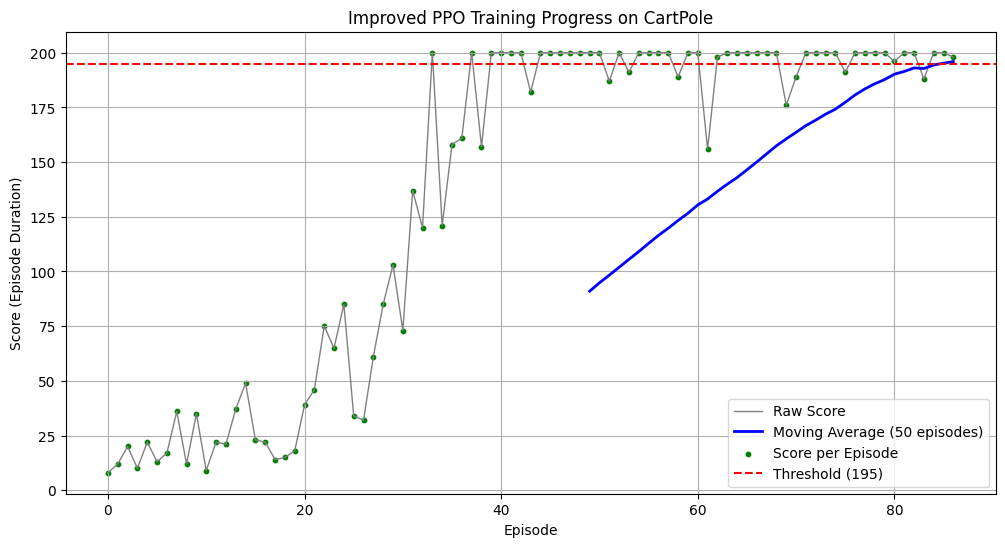

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gym
from torch.distributions import Categorical
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
SEED = 20
np.random.seed(SEED)
torch.manual_seed(SEED)

# Create the environment
env = gym.make('CartPole-v0')
env.seed(SEED)

# Hyperparameters
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
hidden_dim = 64
learning_rate = 0.003
gamma = 0.99
epsilon_clip = 0.2
k_epochs = 4
num_episodes = 1000
max_steps = 500
batch_size = 32

# Get thresholds from environment constraints
theta_threshold = (env.observation_space.high[2]) / 2 - 0.001  # Pole angle
x_threshold = env.observation_space.high[0]  # Cart position

# Define the Actor-Critic Network
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super(ActorCritic, self).__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        action_probs = self.actor(state)
        state_value = self.critic(state)
        return action_probs, state_value

# Initialize the Actor-Critic model
policy = ActorCritic(state_dim, action_dim, hidden_dim).to('cpu')
optimizer = optim.Adam(policy.parameters(), lr=learning_rate)

# PPO Loss function with Entropy Regularization
def compute_ppo_loss_with_entropy(old_log_probs, new_log_probs, advantages, values, returns, action_probs, entropy_coeff=0.01):
    ratios = torch.exp(new_log_probs - old_log_probs)
    clipped_ratios = torch.clamp(ratios, 1 - epsilon_clip, 1 + epsilon_clip)
    actor_loss = -torch.min(ratios * advantages, clipped_ratios * advantages).mean()
    critic_loss = nn.MSELoss()(returns, values)
    entropy_loss = -torch.mean(torch.sum(action_probs * torch.log(action_probs + 1e-10), dim=1))  # Add entropy regularization
    return actor_loss + 0.5 * critic_loss + entropy_coeff * entropy_loss  # Weight for entropy term

# Training Loop
episode_rewards = []
for episode in range(1, num_episodes + 1):
    state = env.reset()
    states, actions, rewards, log_probs, values, dones = [], [], [], [], [], []
    total_reward = 0

    # Collect trajectory
    for t in range(max_steps):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        action_probs, state_value = policy(state_tensor)
        dist = Categorical(action_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        next_state, reward, done, _ = env.step(action.item())

        # Compute custom rewards
        x = abs(next_state[0])  # Cart position (absolute value)
        theta = abs(next_state[2])  # Pole angle (absolute value)
        cart = np.exp((x_threshold - x) / x_threshold) - 0.999  # Cart position reward
        angle = np.exp((theta_threshold - theta) / theta_threshold) - 0.999  # Pole angle reward
        reward = (0.15 * cart) + (0.85 * angle)  # Combined reward

        total_reward += reward

        # Store experience
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob)
        values.append(state_value)
        dones.append(done)

        state = next_state
        if done:
            break

    # Compute returns and advantages
    returns = []
    advantages = []
    G = 0
    for r, value, done in zip(reversed(rewards), reversed(values), reversed(dones)):
        if done:
            G = 0
        G = r + gamma * G
        returns.insert(0, G)
        advantages.insert(0, G - value.item())

    returns = torch.FloatTensor(returns)
    advantages = torch.FloatTensor(advantages)
    log_probs = torch.cat(log_probs)
    values = torch.cat(values).squeeze()

    # Optimize policy using PPO with entropy regularization
    for _ in range(k_epochs):
        for i in range(0, len(states), batch_size):
            # Prepare mini-batches
            state_batch = torch.FloatTensor(states[i:i + batch_size])
            action_batch = torch.tensor(actions[i:i + batch_size])
            advantage_batch = advantages[i:i + batch_size].detach()  # Detach
            return_batch = returns[i:i + batch_size].detach()  # Detach
            old_log_probs_batch = log_probs[i:i + batch_size].detach()  # Detach

            # Recompute log_probs and state values
            action_probs, state_values = policy(state_batch)
            dist = Categorical(action_probs)
            new_log_probs = dist.log_prob(action_batch)

            # Compute PPO loss
            loss = compute_ppo_loss_with_entropy(
                old_log_probs_batch,
                new_log_probs,
                advantage_batch,
                state_values.squeeze(),
                return_batch,
                action_probs
            )

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Logging
    episode_rewards.append(t + 1)  # Count the time steps in the episode as the score
    if episode % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:]) if len(episode_rewards) >= 50 else np.mean(episode_rewards)
        print(f"Episode {episode}, Average Reward: {avg_reward:.2f}")

    # Early stopping condition
    if len(episode_rewards) >= 50 and np.mean(episode_rewards[-50:]) >= 195.6:
        print(f"\nEnvironment solved in {episode} episodes with average reward {np.mean(episode_rewards[-50:]):.2f} over the last 50 episodes.")
        break

# Plot Rewards
score_array = np.array(episode_rewards)
window_size = 50  # Moving average window size
if len(score_array) >= window_size:
    moving_avg = np.convolve(score_array, np.ones(window_size) / window_size, mode='valid')
else:
    moving_avg = score_array

plt.figure(figsize=(12, 6))
plt.plot(score_array, color='gray', linewidth=1, label='Raw Score')
plt.plot(range(window_size - 1, len(score_array)), moving_avg, color='blue', linewidth=2, label=f'Moving Average ({window_size} episodes)')
plt.scatter(range(len(score_array)), score_array, color='green', s=10, label='Score per Episode')
plt.axhline(y=195, color='red', linestyle='--', label='Threshold (195)')
plt.xlabel('Episode')
plt.ylabel('Score (Episode Duration)')
plt.title('Improved PPO Training Progress on CartPole')
plt.legend()
plt.grid(True)
plt.show()


Test scores: [193.0, 200.0, 200.0, 200.0, 165.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 170.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 190.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 161.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 178.0, 200.0, 200.0, 200.0, 200.0, 200.0,

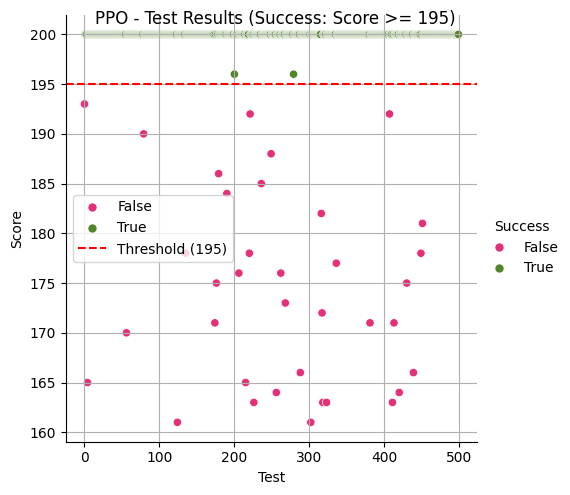

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to test the PPO agent
def test_ppo_agent(policy, i, print_reward=False):
    # Create a test environment
    env = gym.make('CartPole-v0')
    env.seed(i)
    state = env.reset()
    total_reward = 0

    for t in range(200):  # Fixed max steps for testing
        # Get action probabilities from the trained policy
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        action_probs, _ = policy(state_tensor)
        action = torch.argmax(action_probs).item()  # Select the action with the highest probability
        state, reward, done, _ = env.step(action)
        total_reward += reward
        if done:
            break

    env.close()
    if print_reward:
        print(f"Reward: {total_reward}")
    return total_reward

# Function to plot test results
def plot_test_results(method='', total=100):
    test_scores = []
    for i in range(total):
        test_scores.append(test_ppo_agent(policy, i, print_reward=False))

    print(f"Test scores: {test_scores}")

    # Define success as achieving a score >= 195
    colors = {True: "#54852A", False: "#E33079"}
    test_df = pd.DataFrame({'Test': range(total), 'Score': test_scores})
    test_df['Success'] = test_df['Score'] >= 195

    # Print statistics
    print(test_df['Score'].describe())
    success_count = test_df['Success'].value_counts()
    print(success_count)

    # Plot results
    ax = sns.relplot(data=test_df, x="Test", y="Score", hue="Success", palette=colors)
    ax.fig.suptitle(f"{method} - Test Results (Success: Score >= 195)")
    plt.axhline(y=195, color='r', linestyle='--', label='Threshold (195)')
    plt.legend()
    plt.grid()
    plt.show()

# Test and plot results
plot_test_results(method='PPO', total=500)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the cart position reward function
def cart_position_reward(x, x_threshold):
    """
    Computes the reward based on the formula:
    r1 = e^((x_threshold - |x|) / x_threshold) - 0.8
    """
    return np.exp((x_threshold - np.abs(x)) / x_threshold) - 0.999

# Parameters
x_threshold = 2.4  # Cart position threshold for CartPole (in meters)
x_values = np.linspace(-2 * x_threshold, 2 * x_threshold, 500)  # Generate x values

# Compute rewards for each cart position
rewards_r1 = cart_position_reward(x_values, x_threshold)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(x_values, rewards_r1, label='Cart Position Reward (r1)', color='blue', linewidth=2)
plt.axvline(x=x_threshold, color='red', linestyle='--', label='X Threshold')
plt.axvline(x=-x_threshold, color='red', linestyle='--')
plt.axhline(y=0, color='black', linestyle='--', label='Zero Reward Line')

# Labels and title
plt.title("Cart Position Reward Function Visualization (r1)", fontsize=14)
plt.xlabel("X (Cart Position)", fontsize=12)
plt.ylabel("Reward (r1)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()


# Custome Reward Trials - R2 - Pole Angle

/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

Episode 50	Average Reward: 41.28
Episode 100	Average Reward: 128.86
Episode 150	Average Reward: 151.06
Episode 200	Average Reward: 185.86
Episode 250	Average Reward: 195.58

Environment solved in 268 episodes with average reward 195.07 over the last 100 episodes.


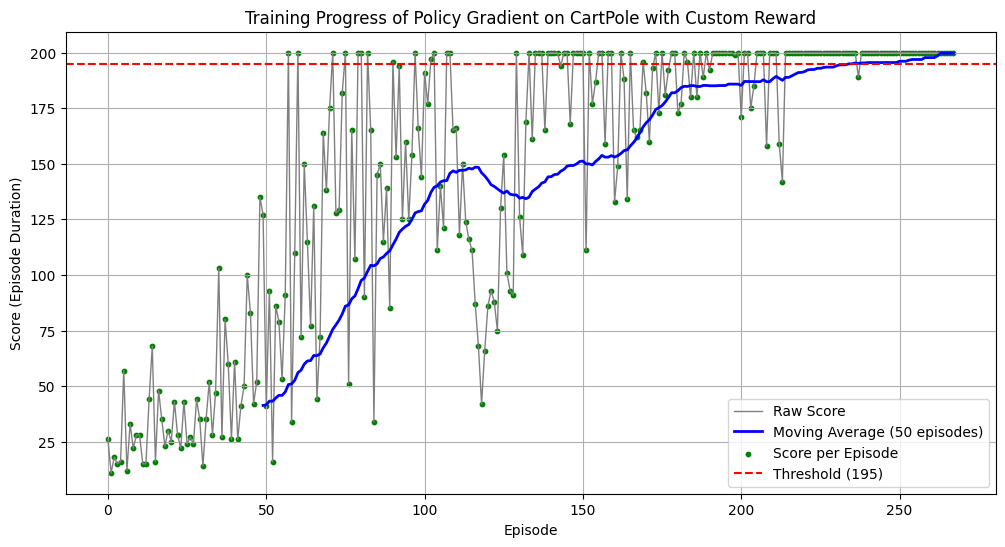

In [ ]:
# Import necessary libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gym
import matplotlib.pyplot as plt

# Set the random seed for reproducibility
seed = 20
np.random.seed(seed)
torch.manual_seed(seed)

# Create the environment
env = gym.make('CartPole-v0')
env.seed(seed)

# Get state and action dimensions
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# Get theta threshold from environment constraints
theta_threshold = (env.observation_space.high[2])/2 - 0.001

# Define the policy network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        probs = self.softmax(x)
        return probs

# Instantiate the policy network
policy_net = PolicyNetwork(state_dim, action_dim, hidden_size=128)

# Set the optimizer
learning_rate = 0.003
optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)

# Training parameters
gamma = 0.95
num_episodes = 500
max_steps = 500

# For logging
episode_rewards = []

for episode in range(1, num_episodes + 1):
    env.seed(episode)
    state = env.reset()
    env.seed(episode)

    state = torch.from_numpy(state).float()
    rewards = []
    log_probs = []

    for t in range(max_steps):
        # Get action probabilities from the policy network
        probs = policy_net(state)
        # Sample an action from the probability distribution
        m = torch.distributions.Categorical(probs)
        action = m.sample()
        log_prob = m.log_prob(action)
        # Step the environment
        next_state, reward, done, _ = env.step(action.item())

        # Compute custom reward
        theta = abs(next_state[2])  # Pole angle (absolute value)
        reward = np.exp(theta_threshold - theta) / theta_threshold - 0.999  # Custom reward

        next_state = torch.from_numpy(next_state).float()
        # Save reward and log probability
        rewards.append(reward)
        log_probs.append(log_prob)
        # Update state
        state = next_state
        if done:
            break

    # Compute the cumulative rewards (returns) for the episode
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns)
    # Normalize returns for better convergence
    returns = (returns - returns.mean()) / (returns.std() + 1e-9)
    # Compute policy gradient loss
    loss = []
    for log_prob, Gt in zip(log_probs, returns):
        loss.append(-log_prob * Gt)
    loss = torch.stack(loss).sum()
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Log episode reward
    episode_rewards.append(t+1)
    # Print progress every 10 episodes
    if episode % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f'Episode {episode}\tAverage Reward: {avg_reward:.2f}')
    # Check for convergence
    if episode >= 100:
        avg_reward = np.mean(episode_rewards[-100:])
        if avg_reward >= 195.0:
            print(f'\nEnvironment solved in {episode} episodes with average reward {avg_reward:.2f} over the last 100 episodes.')
            break

# Close the environment
env.close()

# Convert 'episode_rewards' to a NumPy array for easy manipulation
score_array = np.array(episode_rewards)

# Calculate a moving average with a window size of 50
window_size = 50
if len(score_array) >= window_size:
    moving_avg = np.convolve(score_array, np.ones(window_size)/window_size, mode='valid')
else:
    moving_avg = score_array  # If not enough data points, use the raw scores

# Plot the raw scores and the moving average
plt.figure(figsize=(12, 6))
plt.plot(score_array, color='gray', linewidth=1, label='Raw Score')
plt.plot(range(window_size - 1, len(score_array)), moving_avg, color='blue', linewidth=2, label=f'Moving Average ({window_size} episodes)')
plt.scatter(range(len(score_array)), score_array, color='green', s=10, label='Score per Episode')
plt.axhline(y=195, color='red', linestyle='--', label='Threshold (195)')

# Labels and title
plt.xlabel('Episode')
plt.ylabel('Score (Episode Duration)')
plt.title('Training Progress of Policy Gradient on CartPole with Custom Reward')
plt.legend()
plt.grid(True)
plt.show()


Test Scores Summary:
count    500.0
mean     200.0
std        0.0
min      200.0
25%      200.0
50%      200.0
75%      200.0
max      200.0
Name: Score, dtype: float64
Success Count (Score >= 195):
Success
True    500
Name: count, dtype: int64


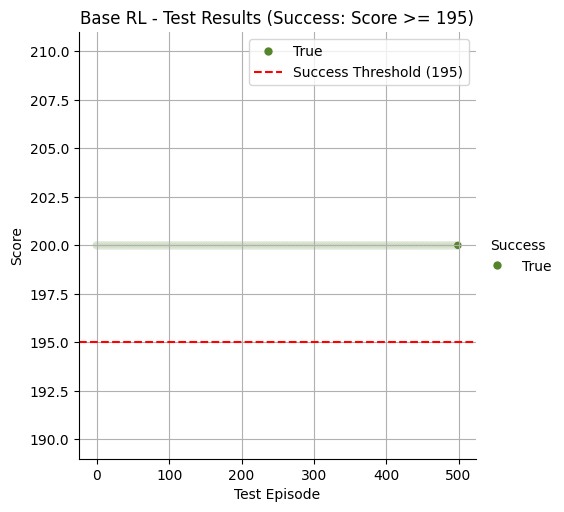

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Function to sample action based on the trained policy
def test_policy_sample(state, policy_net):
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        action_probs = policy_net(state_tensor)
        dist = torch.distributions.Categorical(action_probs)
        action = dist.sample().item()
    return action

# Function to test the agent's performance in one episode
def test_agent_base_rl(seed, print_reward=False):
    env = gym.make('CartPole-v0')
    env.seed(seed)
    state = env.reset()
    rewards = []

    for t in range(200):
        action = test_policy_sample(state, policy_net)
        state, reward, terminated, truncated = env.step(action)
        done = terminated or truncated
        rewards.append(reward)
        if done:
            total_reward = sum(rewards)
            if print_reward:
                print(f"Episode {seed}, Total Reward: {total_reward}")
            return total_reward
    env.close()

# Function to test the agent across multiple episodes and visualize the results
def plot_test_results_base_rl(method='Base RL', total_tests=100):
    test_scores = []
    for i in range(total_tests):
        test_scores.append(test_agent_base_rl(i, print_reward=False))

    # Print summary statistics
    print("Test Scores Summary:")
    test_df = pd.DataFrame({'Test': range(total_tests), 'Score': test_scores})
    test_df['Success'] = test_df['Score'] >= 195
    print(test_df['Score'].describe())

    # Count successes
    success_count = test_df['Success'].value_counts()
    print("Success Count (Score >= 195):")
    print(success_count)

    # Visualization
    colors = {True: "#54852A", False: "#E33079"}
    sns.relplot(data=test_df, x="Test", y="Score", hue="Success", palette=colors)
    plt.axhline(y=195, color='red', linestyle='--', label='Success Threshold (195)')
    plt.title(f"{method} - Test Results (Success: Score >= 195)")
    plt.xlabel("Test Episode")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the testing and plotting function
plot_test_results_base_rl(method="Base RL", total_tests=500)


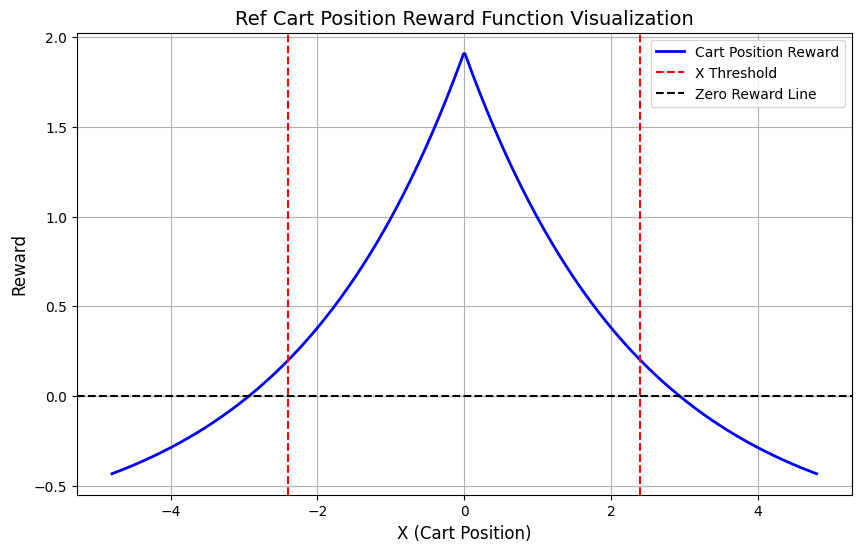

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the cart position reward function
def cart_position_reward(x, x_threshold):
    """
    Computes the reward based on the formula:
    r1 = e^((x_threshold - |x|) / x_threshold) - 0.8
    """
    return np.exp((x_threshold - np.abs(x)) / x_threshold) - 0.8

# Parameters
x_threshold = 2.4  # Cart position threshold for CartPole (in meters)
x_values = np.linspace(-2 * x_threshold, 2 * x_threshold, 500)  # Generate x values

# Compute rewards for each cart position
rewards_r1 = cart_position_reward(x_values, x_threshold)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(x_values, rewards_r1, label='Cart Position Reward', color='blue', linewidth=2)
plt.axvline(x=x_threshold, color='red', linestyle='--', label='X Threshold')
plt.axvline(x=-x_threshold, color='red', linestyle='--')
plt.axhline(y=0, color='black', linestyle='--', label='Zero Reward Line')

# Labels and title
plt.title("Ref Cart Position Reward Function Visualization", fontsize=14)
plt.xlabel("X (Cart Position)", fontsize=12)
plt.ylabel("Reward", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()


In [ ]:
theta = 0
theta_threshold = (env.observation_space.high[2])/2 - 0.001
theta = abs(next_state[2])  # Pole angle (absolute value)
reward = (theta_threshold - theta) / theta_threshold - 0.5
print(theta_threshold)
print(reward)

0.20843951606750488
tensor(0.4264)


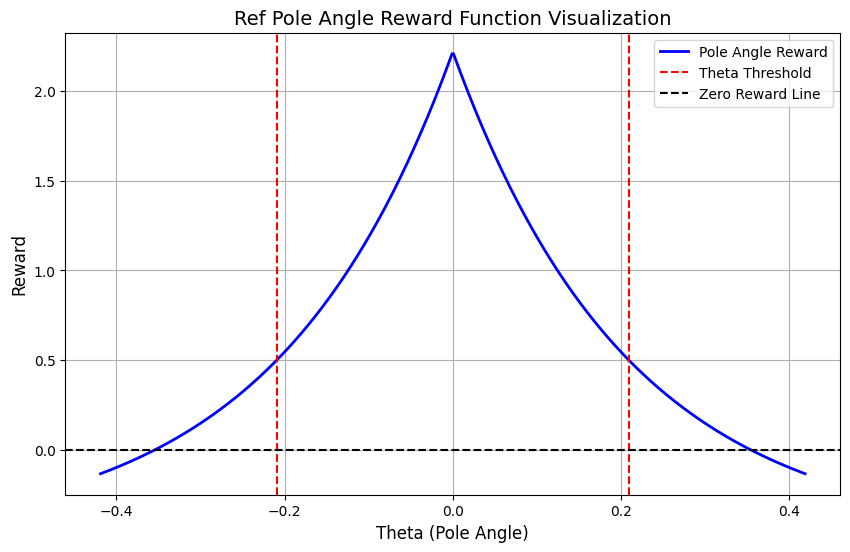

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the custom reward function
def custom_reward(theta, theta_threshold):
    """
    Computes the reward based on the formula:
    r = e^((theta_threshold - |theta|) / theta_threshold) - 0.5
    """
    return np.exp((theta_threshold - np.abs(theta)) / theta_threshold) - 0.5

# Parameters
theta_threshold = 0.20943951  # Pole angle threshold (in radians, ~12 degrees for CartPole)
theta_values = np.linspace(-2 * theta_threshold, 2 * theta_threshold, 500)  # Generate theta values

# Compute rewards for each theta
rewards = custom_reward(theta_values, theta_threshold)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(theta_values, rewards, label='Pole Angle Reward', color='blue', linewidth=2)
plt.axvline(x=theta_threshold, color='red', linestyle='--', label='Theta Threshold')
plt.axvline(x=-theta_threshold, color='red', linestyle='--')
plt.axhline(y=0, color='black', linestyle='--', label='Zero Reward Line')

# Labels and title
plt.title("Ref Pole Angle Reward Function Visualization", fontsize=14)
plt.xlabel("Theta (Pole Angle)", fontsize=12)
plt.ylabel("Reward", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()


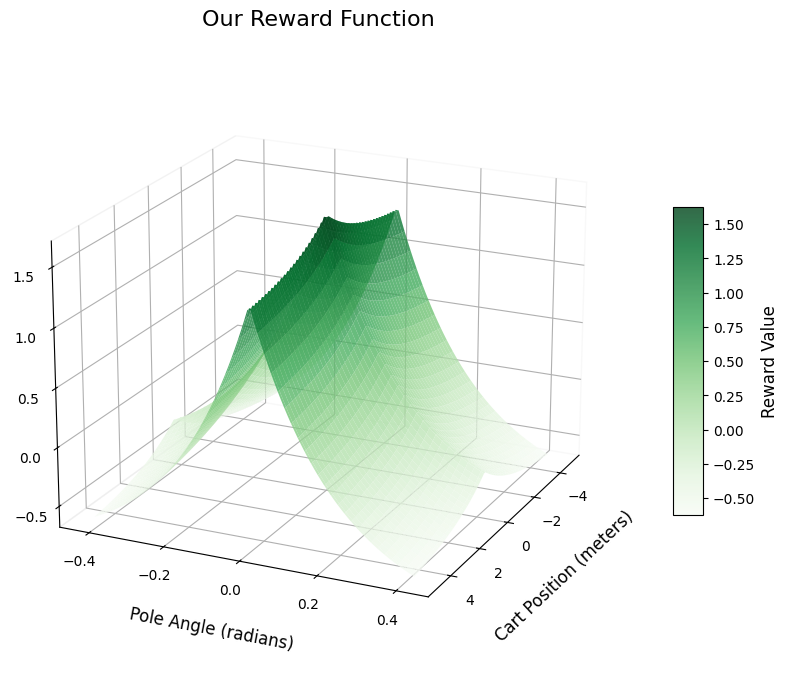

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the cart position reward function
def cart_position_reward(x, x_threshold):
    return np.exp((x_threshold - np.abs(x)) / x_threshold) - 0.999

# Define the pole angle reward function
def pole_angle_reward(theta, theta_threshold):
    return np.exp((theta_threshold - np.abs(theta)) / theta_threshold) - 0.999

# Combined reward function
def combined_reward(x, theta, x_threshold, theta_threshold, w_cart, w_angle):
    cart_reward = cart_position_reward(x, x_threshold)
    angle_reward = pole_angle_reward(theta, theta_threshold)
    return (w_cart * cart_reward) + (w_angle * angle_reward)

# Parameters
x_threshold = 2.4  # Cart position threshold for CartPole
theta_threshold = 0.20943951  # Pole angle threshold (in radians, ~12 degrees for CartPole)
w_cart = 0.15  # Weight for cart position
w_angle = 0.85  # Weight for pole angle

# Generate a grid of cart positions (x) and pole angles (theta)
x_values = np.linspace(-2 * x_threshold, 2 * x_threshold, 100)
theta_values = np.linspace(-2 * theta_threshold, 2 * theta_threshold, 100)
x, theta = np.meshgrid(x_values, theta_values)

# Compute the combined rewards
rewards = combined_reward(x, theta, x_threshold, theta_threshold, w_cart, w_angle)

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(x, theta, rewards, cmap='Greens', edgecolor='none', alpha=0.8)
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("Reward Value", fontsize=12)

# Enhance the title
ax.set_title(
    "Our Reward Function",
    fontsize=16,
    pad=20
)

# Update axis labels
ax.set_xlabel("Cart Position (meters)", fontsize=12, labelpad=15)
ax.set_ylabel("Pole Angle (radians)", fontsize=12, labelpad=15)
ax.set_zlabel("Reward (Weighted Combination)", fontsize=12, labelpad=15)

# Add grid
ax.grid(True, linestyle='--', alpha=0.5)

# Highlight the bounding box for better clarity
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# # Highlight the max reward for better presentation
# max_reward = rewards.max()
# ax.text(0, 0, max_reward, f"Max Reward: {max_reward:.2f}", color='black', fontsize=10)

# Adjust viewing angle for better visualization
ax.view_init(elev=20, azim=25)

# Show the plot
plt.show()


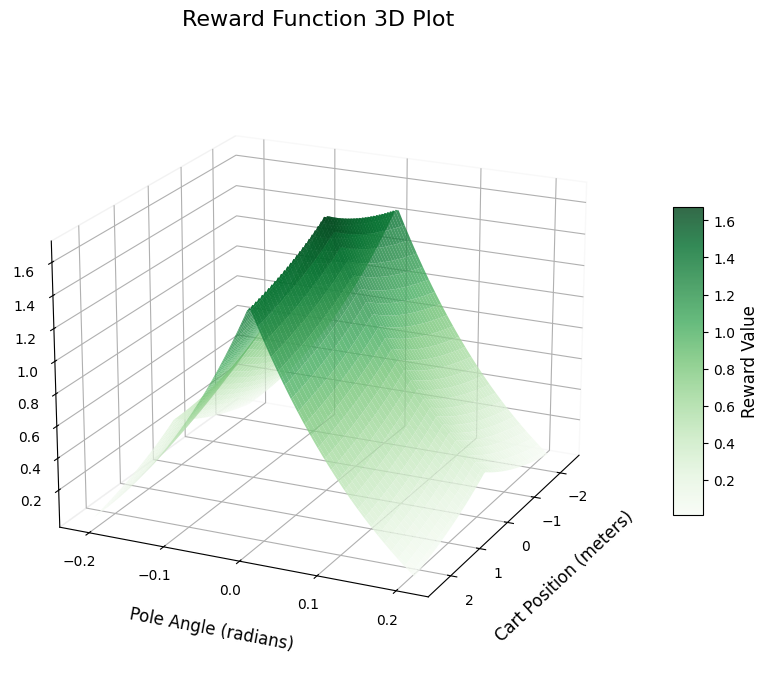

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the cart position reward function
def cart_position_reward(x, x_threshold):
    return np.exp((x_threshold - np.abs(x)) / x_threshold) - 0.999

# Define the pole angle reward function
def pole_angle_reward(theta, theta_threshold):
    return np.exp((theta_threshold - np.abs(theta)) / theta_threshold) - 0.999

# Combined reward function with restriction to zero
def combined_reward(x, theta, x_threshold, theta_threshold, w_cart, w_angle):
    cart_reward = cart_position_reward(x, x_threshold)
    angle_reward = pole_angle_reward(theta, theta_threshold)
    raw_reward = (w_cart * cart_reward) + (w_angle * angle_reward)
    return np.maximum(raw_reward, 0)  # Restrict reward to be non-negative

# Parameters
x_threshold = 2.4  # Cart position threshold for CartPole
theta_threshold = 0.20943951  # Pole angle threshold (in radians, ~12 degrees for CartPole)
w_cart = 0.15  # Weight for cart position
w_angle = 0.85  # Weight for pole angle

# Generate a grid of cart positions (x) and pole angles (theta)
x_values = np.linspace(-x_threshold, x_threshold, 100)
theta_values = np.linspace(-theta_threshold, theta_threshold, 100)
x, theta = np.meshgrid(x_values, theta_values)

# Compute the combined rewards with the restriction applied
rewards = combined_reward(x, theta, x_threshold, theta_threshold, w_cart, w_angle)

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the reward surface
surf = ax.plot_surface(x, theta, rewards, cmap='Greens', edgecolor='none', alpha=0.8)
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("Reward Value", fontsize=12)

# # Add cart position threshold planes (x = ±2.4) spanning to the axes
# x_positive_plane = np.full_like(theta, x_threshold)
# x_negative_plane = np.full_like(theta, -x_threshold)
# z_range = np.linspace(rewards.min(), rewards.max(), len(theta_values))
# theta_full = np.linspace(-2 * theta_threshold, 2 * theta_threshold, len(theta_values))

# ax.plot_surface(
#     x_positive_plane, np.tile(theta_full, (len(z_range), 1)).T, np.tile(z_range, (len(theta_full), 1)),
#     color='red', alpha=0.1, edgecolor='none'
# )
# ax.plot_surface(
#     x_negative_plane, np.tile(theta_full, (len(z_range), 1)).T, np.tile(z_range, (len(theta_full), 1)),
#     color='red', alpha=0.1, edgecolor='none'
# )

# # Add pole angle threshold planes (theta = ±0.20943951) spanning to the axes
# theta_positive_plane = np.full_like(x, theta_threshold)
# theta_negative_plane = np.full_like(x, -theta_threshold)
# x_full = np.linspace(-2 * x_threshold, 2 * x_threshold, len(x_values))

# ax.plot_surface(
#     np.tile(x_full, (len(z_range), 1)), theta_positive_plane, np.tile(z_range, (len(x_full), 1)).T,
#     color='red', alpha=0.1, edgecolor='none'
# )
# ax.plot_surface(
#     np.tile(x_full, (len(z_range), 1)), theta_negative_plane, np.tile(z_range, (len(x_full), 1)).T,
#     color='red', alpha=0.1, edgecolor='none'
# )

# # Add zero plane (z = 0) spanning to the axes
# z_zero_plane = np.zeros_like(x)
# ax.plot_surface(
#     x, theta, z_zero_plane, color='blue', alpha=0.2, edgecolor='none', label="Zero Plane"
# )

# Enhance the title
ax.set_title(
    "Reward Function 3D Plot",
    fontsize=16,
    pad=20
)

# Update axis labels
ax.set_xlabel("Cart Position (meters)", fontsize=12, labelpad=15)
ax.set_ylabel("Pole Angle (radians)", fontsize=12, labelpad=15)
# ax.set_zlabel("Reward (Weighted Combination)", fontsize=12, labelpad=15)

# Add grid
ax.grid(True, linestyle='--', alpha=0.5)

# Highlight the bounding box for better clarity
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Adjust viewing angle for better visualization
ax.view_init(elev=20, azim=25)

# ax.w_zaxis.line.set_lw(0.)
# ax.set_zticks([])

# Show the plot
plt.show()




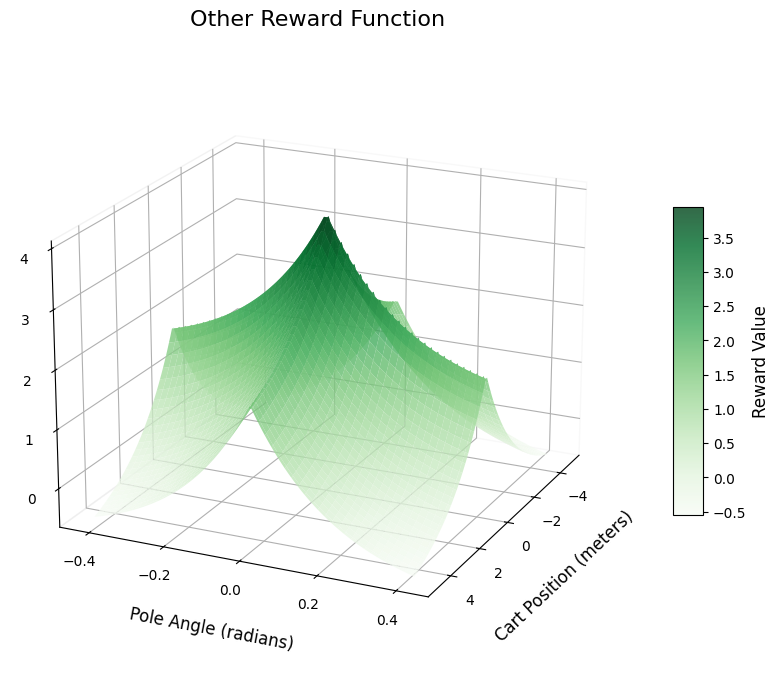

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the cart position reward function
def cart_position_reward(x, x_threshold):
    return np.exp((x_threshold - np.abs(x)) / x_threshold) - 0.8

# Define the pole angle reward function
def pole_angle_reward(theta, theta_threshold):
    return np.exp((theta_threshold - np.abs(theta)) / theta_threshold) - 0.5

# Combined reward function
def combined_reward(x, theta, x_threshold, theta_threshold, w_cart, w_angle):
    cart_reward = cart_position_reward(x, x_threshold)
    angle_reward = pole_angle_reward(theta, theta_threshold)
    return (w_cart * cart_reward) + (w_angle * angle_reward)

# Parameters
x_threshold = 2.4  # Cart position threshold for CartPole
theta_threshold = 0.20943951  # Pole angle threshold (in radians, ~12 degrees for CartPole)
w_cart = 1  # Weight for cart position
w_angle = 1  # Weight for pole angle

# Generate a grid of cart positions (x) and pole angles (theta)
x_values = np.linspace(-2 * x_threshold, 2 * x_threshold, 100)
theta_values = np.linspace(-2 * theta_threshold, 2 * theta_threshold, 100)
x, theta = np.meshgrid(x_values, theta_values)

# Compute the combined rewards
rewards = combined_reward(x, theta, x_threshold, theta_threshold, w_cart, w_angle)

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(x, theta, rewards, cmap='Greens', edgecolor='none', alpha=0.8)
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("Reward Value", fontsize=12)

# Enhance the title
ax.set_title(
    "Other Reward Function",
    fontsize=16,
    pad=20
)

# Update axis labels
ax.set_xlabel("Cart Position (meters)", fontsize=12, labelpad=15)
ax.set_ylabel("Pole Angle (radians)", fontsize=12, labelpad=15)
ax.set_zlabel("Reward (Weighted Combination)", fontsize=12, labelpad=15)

# Add grid
ax.grid(True, linestyle='--', alpha=0.5)

# Highlight the bounding box for better clarity
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Highlight the max reward for better presentation
# max_reward = rewards.max()
# ax.text(0, 0, max_reward, f"Max Reward: {max_reward:.2f}", color='black', fontsize=10)

# Adjust viewing angle for better visualization
ax.view_init(elev=20, azim=25)

# Show the plot
plt.show()


In [ ]:
def step(self, action):
    # Original step function
    obs, reward, done, info = super(CustomCartPoleEnv, self).step(action)
    # Modify the reward
    x, x_dot, theta, theta_dot = obs
    # Penalize the cart for being away from center
    # 0 to 005
    reward -= abs(x) * 0.1
    # Penalize the pole angle deviation
    reward -= abs(theta) * 0.5
    return obs, reward, done, info

# 1. Best hyperparameter combination model

---


Episode 50	Average Reward: 41.90
Episode 100	Average Reward: 107.22
Episode 150	Average Reward: 182.28
Episode 200	Average Reward: 183.70
Episode 250	Average Reward: 173.50
Episode 300	Average Reward: 199.56

Environment solved in 328 episodes with average reward 195.12 over the last 100 episodes.


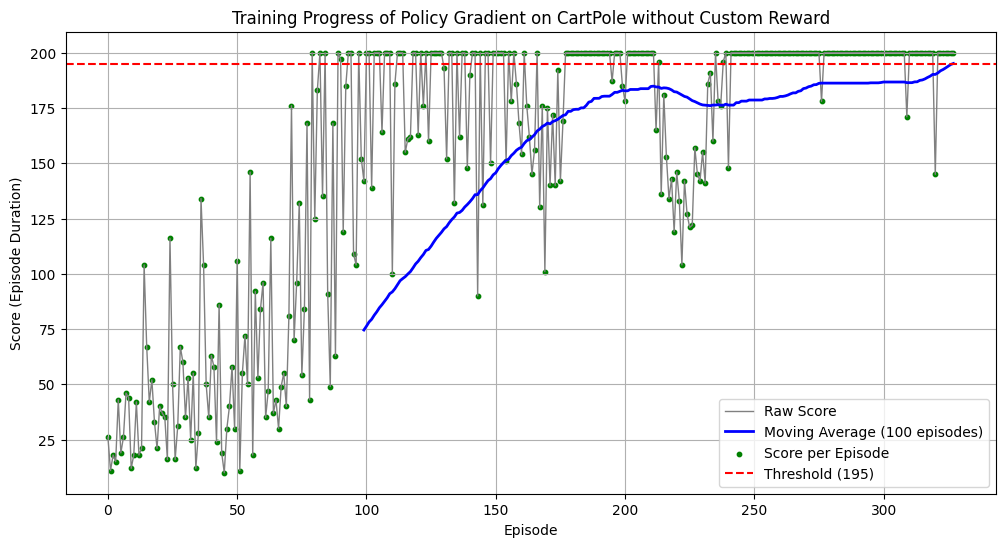

In [ ]:
# Import necessary libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gym

# Set the random seed for reproducibility
seed = 20
np.random.seed(seed)
torch.manual_seed(seed)

# Create the environment
env = gym.make('CartPole-v0')
env.seed(seed)

# Get state and action dimensions
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# Define the policy network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        probs = self.softmax(x)
        return probs

# Instantiate the policy network
policy_net = PolicyNetwork(state_dim, action_dim, hidden_size=128)

# Set the optimizer
learning_rate = 0.003
optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)

# Training parameters
gamma = 0.95
num_episodes = 500
max_steps = 500

# For logging
episode_rewards = []

for episode in range(1, num_episodes + 1):
    env.seed(episode)
    state = env.reset()
    env.seed(episode)

    state = torch.from_numpy(state).float()
    rewards = []
    log_probs = []

    for t in range(max_steps):
        # Get action probabilities from the policy network
        probs = policy_net(state)
        # Sample an action from the probability distribution
        m = torch.distributions.Categorical(probs)
        action = m.sample()
        log_prob = m.log_prob(action)
        # Step the environment
        next_state, reward, done, _ = env.step(action.item())
        next_state = torch.from_numpy(next_state).float()
        # Save reward and log probability
        rewards.append(reward)
        log_probs.append(log_prob)
        # Update state
        state = next_state
        if done:
            break
    # Compute the cumulative rewards (returns) for the episode
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns)
    # Normalize returns for better convergence
    returns = (returns - returns.mean()) / (returns.std() + 1e-9)
    # Compute policy gradient loss
    loss = []
    for log_prob, Gt in zip(log_probs, returns):
        loss.append(-log_prob * Gt)
    loss = torch.stack(loss).sum()
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Log episode reward
    episode_rewards.append(sum(rewards))
    # Print progress every 10 episodes
    if episode % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f'Episode {episode}\tAverage Reward: {avg_reward:.2f}')
    # Check for convergence
    if episode >= 100:
        avg_reward = np.mean(episode_rewards[-100:])
        if avg_reward >= 195.0:
            print(f'\nEnvironment solved in {episode} episodes with average reward {avg_reward:.2f} over the last 100 episodes.')
            break

# Close the environment
env.close()


import matplotlib.pyplot as plt
import numpy as np

# Convert 'episode_rewards' to a NumPy array for easy manipulation
score_array = np.array(episode_rewards)

# Calculate a moving average with a window size of 50
window_size = 100
if len(score_array) >= window_size:
    moving_avg = np.convolve(score_array, np.ones(window_size)/window_size, mode='valid')
else:
    moving_avg = score_array  # If not enough data points, use the raw scores

# Plot the raw scores and the moving average
plt.figure(figsize=(12, 6))
plt.plot(score_array, color='gray', linewidth=1, label='Raw Score')
plt.plot(range(window_size - 1, len(score_array)), moving_avg, color='blue', linewidth=2, label=f'Moving Average ({window_size} episodes)')
plt.scatter(range(len(score_array)), score_array, color='green', s=10, label='Score per Episode')
plt.axhline(y=195, color='red', linestyle='--', label='Threshold (195)')

# Labels and title
plt.xlabel('Episode')
plt.ylabel('Score (Episode Duration)')
plt.title('Training Progress of Policy Gradient on CartPole without Custom Reward')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

Test Scores Summary:
count    100.00000
mean     196.22000
std       16.73174
min       82.00000
25%      200.00000
50%      200.00000
75%      200.00000
max      200.00000
Name: Score, dtype: float64
Success Count (Score >= 195):
Success
True     92
False     8
Name: count, dtype: int64


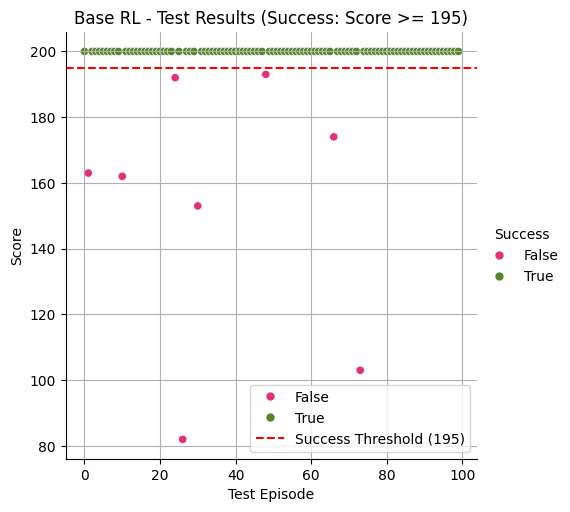

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Function to sample action based on the trained policy
def test_policy_sample(state, policy_net):
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        action_probs = policy_net(state_tensor)
        dist = torch.distributions.Categorical(action_probs)
        action = dist.sample().item()
    return action

# Function to test the agent's performance in one episode
def test_agent_base_rl(seed, print_reward=False):
    env = gym.make('CartPole-v0')
    env.seed(seed)
    state = env.reset()
    rewards = []

    for t in range(200):
        action = test_policy_sample(state, policy_net)
        state, reward, terminated, truncated = env.step(action)
        done = terminated or truncated
        rewards.append(reward)
        if done:
            total_reward = sum(rewards)
            if print_reward:
                print(f"Episode {seed}, Total Reward: {total_reward}")
            return total_reward
    env.close()

# Function to test the agent across multiple episodes and visualize the results
def plot_test_results_base_rl(method='Base RL', total_tests=100):
    test_scores = []
    for i in range(total_tests):
        test_scores.append(test_agent_base_rl(i, print_reward=False))

    # Print summary statistics
    print("Test Scores Summary:")
    test_df = pd.DataFrame({'Test': range(total_tests), 'Score': test_scores})
    test_df['Success'] = test_df['Score'] >= 195
    print(test_df['Score'].describe())

    # Count successes
    success_count = test_df['Success'].value_counts()
    print("Success Count (Score >= 195):")
    print(success_count)

    # Visualization
    colors = {True: "#54852A", False: "#E33079"}
    sns.relplot(data=test_df, x="Test", y="Score", hue="Success", palette=colors)
    plt.axhline(y=195, color='red', linestyle='--', label='Success Threshold (195)')
    plt.title(f"{method} - Test Results (Success: Score >= 195)")
    plt.xlabel("Test Episode")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the testing and plotting function
plot_test_results_base_rl(method="Base RL", total_tests=100)


# DQN

/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

Episode 50	Average Reward: 27.70
Episode 100	Average Reward: 32.24
Episode 150	Average Reward: 36.48
Episode 200	Average Reward: 59.50
Episode 250	Average Reward: 78.72
Episode 300	Average Reward: 124.30
Episode 350	Average Reward: 151.02
Episode 400	Average Reward: 183.98
Episode 450	Average Reward: 197.54
Episode 500	Average Reward: 156.98


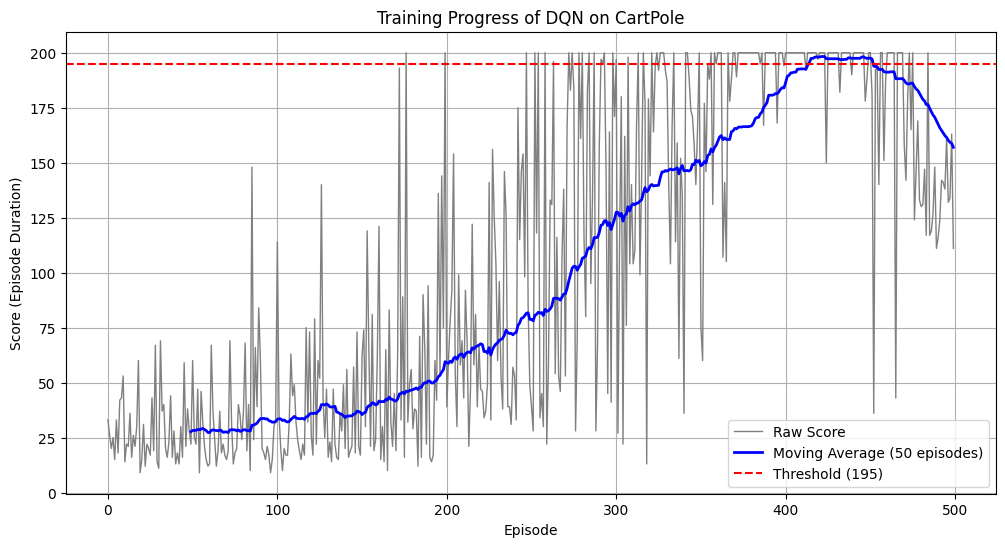

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gym
import random
from collections import deque
import matplotlib.pyplot as plt

# Set the random seed for reproducibility
seed = 20
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# Create the environment
env = gym.make('CartPole-v0')
env.seed(seed)

# Get state and action dimensions
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# Define the Q-network
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size=128):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)  # Outputs Q-values for all actions
        return x

# Instantiate the Q-network and target network
q_net = QNetwork(state_dim, action_dim, hidden_size=128)
target_net = QNetwork(state_dim, action_dim, hidden_size=128)
target_net.load_state_dict(q_net.state_dict())  # Initialize target network weights
target_net.eval()

# Set optimizer and loss function
learning_rate = 0.001
optimizer = optim.Adam(q_net.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

# Hyperparameters
gamma = 0.95  # Discount factor
batch_size = 64
buffer_size = 10000
epsilon_start = 1.0  # Initial exploration probability
epsilon_end = 0.01  # Final exploration probability
epsilon_decay = 500  # Decay rate
target_update_freq = 10  # Update target network every 10 episodes
num_episodes = 500
max_steps = 500

# Replay buffer
replay_buffer = deque(maxlen=buffer_size)

# Function to select action (epsilon-greedy policy)
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()  # Explore
    else:
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = q_net(state_tensor)
        return torch.argmax(q_values).item()  # Exploit

# Function to train the Q-network
def train_q_network():
    if len(replay_buffer) < batch_size:
        return

    # Sample a batch from the replay buffer
    batch = random.sample(replay_buffer, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    # Convert to tensors
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones).unsqueeze(1)

    # Compute Q-values and target Q-values
    q_values = q_net(states).gather(1, actions)
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1, keepdim=True)[0]
        target_q_values = rewards + gamma * next_q_values * (1 - dones)

    # Compute loss and update the network
    loss = loss_fn(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Training loop
epsilon = epsilon_start
episode_rewards = []

for episode in range(1, num_episodes + 1):
    state = env.reset()
    total_reward = 0

    for t in range(max_steps):
        # Select action using epsilon-greedy policy
        action = select_action(state, epsilon)
        next_state, reward, done, _ = env.step(action)
        total_reward += reward

        # Store transition in replay buffer
        replay_buffer.append((state, action, reward, next_state, float(done)))

        # Train the Q-network
        train_q_network()

        # Update state
        state = next_state
        if done:
            break

    # Decay epsilon
    epsilon = max(epsilon_end, epsilon_start - (episode / epsilon_decay))

    # Update target network
    if episode % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

    # Log episode reward
    episode_rewards.append(total_reward)

    # Print progress every 50 episodes
    if episode % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode}\tAverage Reward: {avg_reward:.2f}")

    # Check for convergence
    if episode >= 100:
        avg_reward = np.mean(episode_rewards[-100:])
        if avg_reward >= 195.0:
            print(f"\nEnvironment solved in {episode} episodes with average reward {avg_reward:.2f} over the last 100 episodes.")
            break

# Close the environment
env.close()

# Plot the rewards
score_array = np.array(episode_rewards)
window_size = 50
moving_avg = np.convolve(score_array, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(score_array, color='gray', linewidth=1, label='Raw Score')
plt.plot(range(window_size - 1, len(score_array)), moving_avg, color='blue', linewidth=2, label=f'Moving Average ({window_size} episodes)')
plt.axhline(y=195, color='red', linestyle='--', label='Threshold (195)')
plt.xlabel('Episode')
plt.ylabel('Score (Episode Duration)')
plt.title('Training Progress of DQN on CartPole')
plt.legend()
plt.grid(True)
plt.show()


# custom reward DQN

Episode 50	Average Reward: 73.79
Episode 100	Average Reward: 96.16
Episode 150	Average Reward: 152.10
Episode 200	Average Reward: 227.53

Environment solved in 204 episodes with average reward 199.99 over the last 100 episodes.


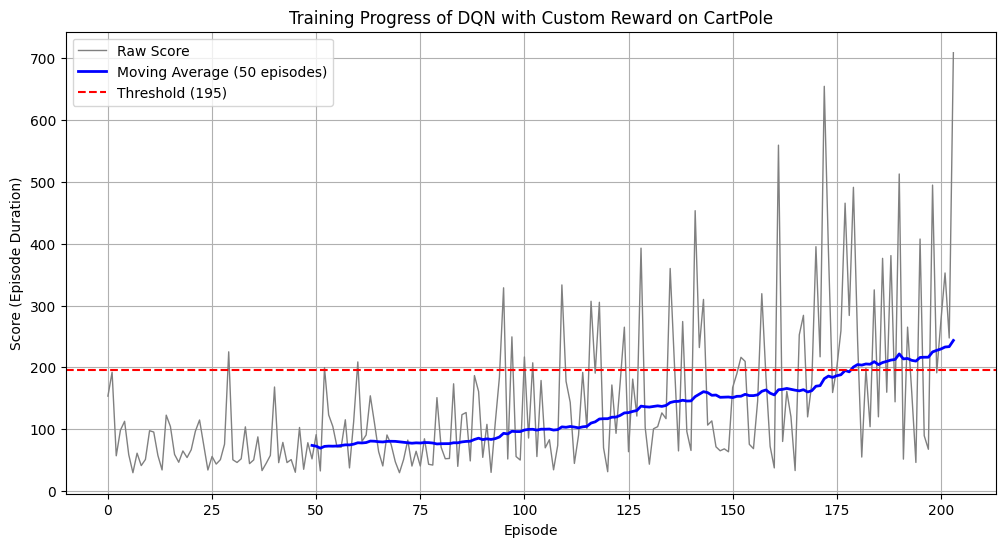

In [ ]:
# Import necessary libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gym
import random
from collections import deque
import matplotlib.pyplot as plt

# Set the random seed for reproducibility
seed = 20
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# Create the environment
env = gym.make('CartPole-v0')
env.seed(seed)

# Get state and action dimensions
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# Define the Q-network
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size=128):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)  # Outputs Q-values for all actions
        return x

# Instantiate the Q-network and target network
q_net = QNetwork(state_dim, action_dim, hidden_size=128)
target_net = QNetwork(state_dim, action_dim, hidden_size=128)
target_net.load_state_dict(q_net.state_dict())  # Initialize target network weights
target_net.eval()

# Set optimizer and loss function
learning_rate = 0.001
optimizer = optim.Adam(q_net.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

# Hyperparameters
gamma = 0.95  # Discount factor
batch_size = 64
buffer_size = 10000
epsilon_start = 1.0  # Initial exploration probability
epsilon_end = 0.01  # Final exploration probability
epsilon_decay = 500  # Decay rate
target_update_freq = 10  # Update target network every 10 episodes
num_episodes = 500
max_steps = 500

# Replay buffer
replay_buffer = deque(maxlen=buffer_size)

# Custom reward function
theta_threshold = (env.observation_space.high[2]) / 2 - 0.001  # Pole angle
x_threshold = env.observation_space.high[0]  # Cart position

def compute_custom_reward(state):
    x = abs(state[0])  # Cart position (absolute value)
    theta = abs(state[2])  # Pole angle (absolute value)

    # Compute custom rewards
    cart = np.exp((x_threshold - x) / x_threshold) - 0.8  # Cart position reward
    angle = np.exp((theta_threshold - theta) / theta_threshold) - 0.5  # Pole angle reward
    reward = (1 * cart) + (1 * angle)  # Combined reward
    return reward

# Function to select action (epsilon-greedy policy)
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()  # Explore
    else:
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = q_net(state_tensor)
        return torch.argmax(q_values).item()  # Exploit

# Function to train the Q-network
def train_q_network():
    if len(replay_buffer) < batch_size:
        return

    # Sample a batch from the replay buffer
    batch = random.sample(replay_buffer, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    # Convert to tensors
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones).unsqueeze(1)

    # Compute Q-values and target Q-values
    q_values = q_net(states).gather(1, actions)
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1, keepdim=True)[0]
        target_q_values = rewards + gamma * next_q_values * (1 - dones)

    # Compute loss and update the network
    loss = loss_fn(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Training loop
epsilon = epsilon_start
episode_rewards = []

for episode in range(1, num_episodes + 1):
    state = env.reset()
    total_reward = 0

    for t in range(max_steps):
        # Select action using epsilon-greedy policy
        action = select_action(state, epsilon)
        next_state, _, done, _ = env.step(action)

        # Compute custom reward
        reward = compute_custom_reward(next_state)
        total_reward += reward

        # Store transition in replay buffer
        replay_buffer.append((state, action, reward, next_state, float(done)))

        # Train the Q-network
        train_q_network()

        # Update state
        state = next_state
        if done:
            break

    # Decay epsilon
    epsilon = max(epsilon_end, epsilon_start - (episode / epsilon_decay))

    # Update target network
    if episode % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

    # Log episode reward
    episode_rewards.append(total_reward)

    # Print progress every 50 episodes
    if episode % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode}\tAverage Reward: {avg_reward:.2f}")

    # Check for convergence
    if episode >= 100:
        avg_reward = np.mean(episode_rewards[-100:])
        if avg_reward >= 195.0:
            print(f"\nEnvironment solved in {episode} episodes with average reward {avg_reward:.2f} over the last 100 episodes.")
            break

# Close the environment
env.close()

# Plot the rewards
score_array = np.array(episode_rewards)
window_size = 50
moving_avg = np.convolve(score_array, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(score_array, color='gray', linewidth=1, label='Raw Score')
plt.plot(range(window_size - 1, len(score_array)), moving_avg, color='blue', linewidth=2, label=f'Moving Average ({window_size} episodes)')
plt.axhline(y=195, color='red', linestyle='--', label='Threshold (195)')
plt.xlabel('Episode')
plt.ylabel('Score (Episode Duration)')
plt.title('Training Progress of DQN with Custom Reward on CartPole')
plt.legend()
plt.grid(True)
plt.show()


# 3. PPO Trials

/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

Episode 50, Average Reward: 93.92
Episode 100, Average Reward: 169.78
Episode 150, Average Reward: 183.98
Episode 200, Average Reward: 171.44
Episode 250, Average Reward: 191.26
Episode 300, Average Reward: 189.52
Episode 350, Average Reward: 188.10
Episode 400, Average Reward: 190.40
Episode 450, Average Reward: 192.88
Episode 500, Average Reward: 191.04
Episode 550, Average Reward: 175.06
Episode 600, Average Reward: 165.10
Episode 650, Average Reward: 193.94
Episode 700, Average Reward: 187.62
Episode 750, Average Reward: 185.26
Episode 800, Average Reward: 187.14
Episode 850, Average Reward: 185.88
Episode 900, Average Reward: 196.08
Episode 950, Average Reward: 187.96
Episode 1000, Average Reward: 193.02


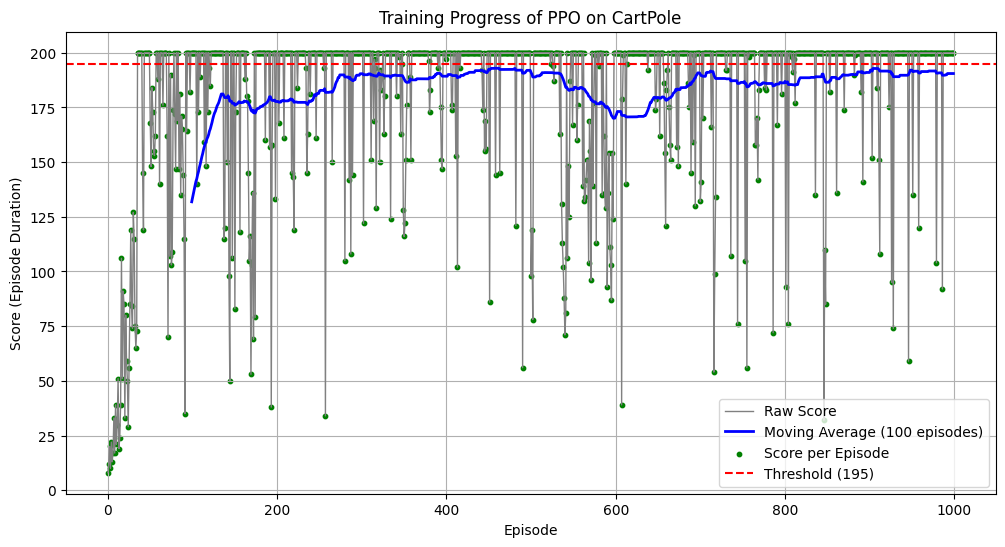

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gym
from torch.distributions import Categorical
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
SEED = 20
np.random.seed(SEED)
torch.manual_seed(SEED)

# Create the environment
env = gym.make('CartPole-v0')
env.seed(SEED)

# Hyperparameters
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
hidden_dim = 64
learning_rate = 0.003
gamma = 0.99
epsilon_clip = 0.2
k_epochs = 4
num_episodes = 1000
max_steps = 500
batch_size = 32

# Define the Actor-Critic Network
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super(ActorCritic, self).__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        action_probs = self.actor(state)
        state_value = self.critic(state)
        return action_probs, state_value

# Initialize the Actor-Critic model
policy = ActorCritic(state_dim, action_dim, hidden_dim).to('cpu')
optimizer = optim.Adam(policy.parameters(), lr=learning_rate)

# PPO Loss function
def compute_ppo_loss(old_log_probs, new_log_probs, advantages, values, returns):
    ratios = torch.exp(new_log_probs - old_log_probs)
    clipped_ratios = torch.clamp(ratios, 1 - epsilon_clip, 1 + epsilon_clip)
    actor_loss = -torch.min(ratios * advantages, clipped_ratios * advantages).mean()
    critic_loss = nn.MSELoss()(returns, values)
    return actor_loss + 0.5 * critic_loss

# Training Loop
episode_rewards = []
for episode in range(1, num_episodes + 1):
    state = env.reset()
    states, actions, rewards, log_probs, values, dones = [], [], [], [], [], []
    total_reward = 0

    # Collect trajectory
    for _ in range(max_steps):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        action_probs, state_value = policy(state_tensor)
        dist = Categorical(action_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        next_state, reward, done, _ = env.step(action.item())
        total_reward += reward

        # Store experience
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob)
        values.append(state_value)
        dones.append(done)

        state = next_state
        if done:
            break

    # Compute returns and advantages
    returns = []
    advantages = []
    G = 0
    for r, value, done in zip(reversed(rewards), reversed(values), reversed(dones)):
        if done:
            G = 0
        G = r + gamma * G
        returns.insert(0, G)
        advantages.insert(0, G - value.item())

    returns = torch.FloatTensor(returns)
    advantages = torch.FloatTensor(advantages)
    log_probs = torch.cat(log_probs)
    values = torch.cat(values).squeeze()

    # Optimize policy using PPO
    for _ in range(k_epochs):
        for i in range(0, len(states), batch_size):
            # Prepare mini-batches
            state_batch = torch.FloatTensor(states[i:i + batch_size])
            action_batch = torch.tensor(actions[i:i + batch_size])
            advantage_batch = advantages[i:i + batch_size].detach()  # Detach
            return_batch = returns[i:i + batch_size].detach()  # Detach
            old_log_probs_batch = log_probs[i:i + batch_size].detach()  # Detach

            # Recompute log_probs and state values
            action_probs, state_values = policy(state_batch)
            dist = Categorical(action_probs)
            new_log_probs = dist.log_prob(action_batch)

            # Compute PPO loss
            loss = compute_ppo_loss(
                old_log_probs_batch,
                new_log_probs,
                advantage_batch,
                state_values.squeeze(),
                return_batch
            )

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Logging
    episode_rewards.append(total_reward)
    if episode % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:]) if len(episode_rewards) >= 50 else np.mean(episode_rewards)
        print(f"Episode {episode}, Average Reward: {avg_reward:.2f}")

    # Early stopping condition
    if len(episode_rewards) >= 100 and np.mean(episode_rewards[-100:]) >= 195.6:
        print(f"\nEnvironment solved in {episode} episodes with average reward {np.mean(episode_rewards[-100:]):.2f} over the last 100 episodes.")
        break

# Plot Rewards using the template style
score_array = np.array(episode_rewards)
window_size = 100  # Moving average window size
if len(score_array) >= window_size:
    moving_avg = np.convolve(score_array, np.ones(window_size) / window_size, mode='valid')
else:
    moving_avg = score_array

plt.figure(figsize=(12, 6))
plt.plot(score_array, color='gray', linewidth=1, label='Raw Score')
plt.plot(range(window_size - 1, len(score_array)), moving_avg, color='blue', linewidth=2, label=f'Moving Average ({window_size} episodes)')
plt.scatter(range(len(score_array)), score_array, color='green', s=10, label='Score per Episode')
plt.axhline(y=195, color='red', linestyle='--', label='Threshold (195)')
plt.xlabel('Episode')
plt.ylabel('Score (Episode Duration)')
plt.title('Training Progress of PPO on CartPole')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

Test Scores Summary:
count    100.0
mean     200.0
std        0.0
min      200.0
25%      200.0
50%      200.0
75%      200.0
max      200.0
Name: Score, dtype: float64
Success Count (Score >= 195):
Success
True    100
Name: count, dtype: int64


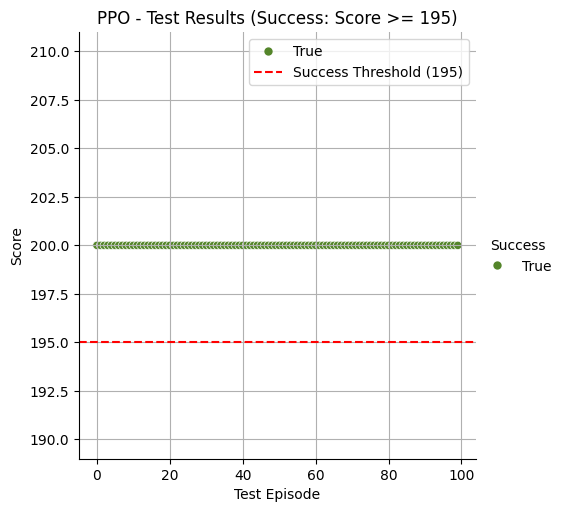

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to sample action based on the trained policy
def test_ppo_policy_sample(state, policy):
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        action_probs, _ = policy(state_tensor)
        dist = Categorical(action_probs)
        action = dist.sample().item()
    return action

# Function to test the agent's performance in one episode
def test_agent_ppo(seed, print_reward=False):
    env = gym.make('CartPole-v0')
    env.seed(seed)
    state = env.reset()
    rewards = []

    for t in range(200):
        action = test_ppo_policy_sample(state, policy)
        state, reward, terminated, truncated = env.step(action)
        done = terminated or truncated
        rewards.append(reward)
        if done:
            total_reward = sum(rewards)
            if print_reward:
                print(f"Episode {seed}, Total Reward: {total_reward}")
            return total_reward
    env.close()

# Function to test the agent across multiple episodes and visualize the results
def plot_test_results_ppo(method='PPO', total_tests=100):
    test_scores = []
    for i in range(total_tests):
        test_scores.append(test_agent_ppo(i, print_reward=False))

    # Print summary statistics
    print("Test Scores Summary:")
    test_df = pd.DataFrame({'Test': range(total_tests), 'Score': test_scores})
    test_df['Success'] = test_df['Score'] >= 195
    print(test_df['Score'].describe())

    # Count successes
    success_count = test_df['Success'].value_counts()
    print("Success Count (Score >= 195):")
    print(success_count)

    # Visualization
    colors = {True: "#54852A", False: "#E33079"}
    sns.relplot(data=test_df, x="Test", y="Score", hue="Success", palette=colors)
    plt.axhline(y=195, color='red', linestyle='--', label='Success Threshold (195)')
    plt.title(f"{method} - Test Results (Success: Score >= 195)")
    plt.xlabel("Test Episode")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the testing and plotting function
plot_test_results_ppo(method="PPO", total_tests=100)


# 4. V10 PPO with entropy, LR Sched, BS, Epoch, CVLW

/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

Episode 50, Average Reward: 54.54
Episode 100, Average Reward: 159.62
Episode 150, Average Reward: 183.04
Episode 200, Average Reward: 195.14

Environment solved in 206 episodes with average reward 195.92 over the last 50 episodes.


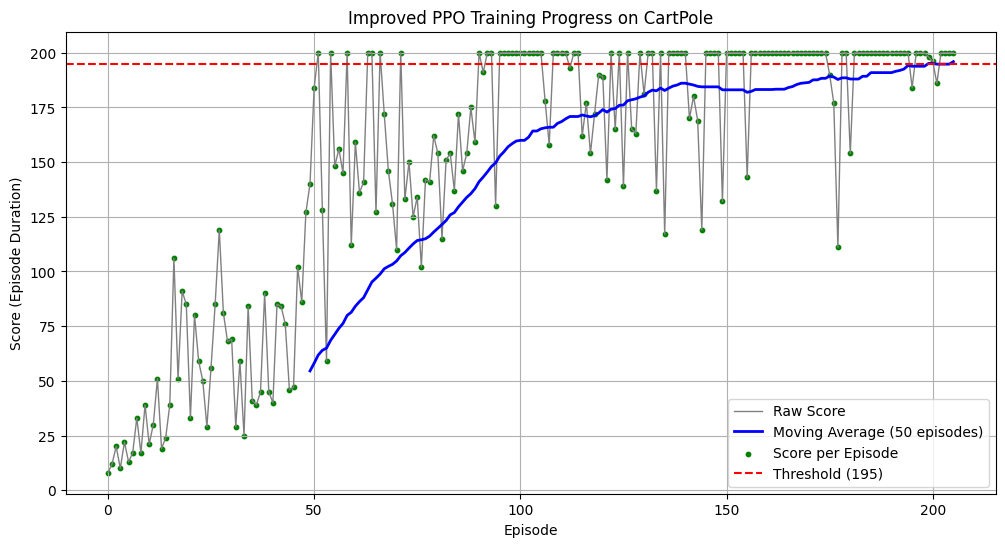

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gym
from torch.distributions import Categorical
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
SEED = 20
np.random.seed(SEED)
torch.manual_seed(SEED)

# Create the environment
env = gym.make('CartPole-v0')
env.seed(SEED)

# Hyperparameters
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
hidden_dim = 64
learning_rate = 0.003
gamma = 0.99
epsilon_clip = 0.2
k_epochs = 4
num_episodes = 1000
max_steps = 500
batch_size = 32

# Define the Actor-Critic Network
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super(ActorCritic, self).__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        action_probs = self.actor(state)
        state_value = self.critic(state)
        return action_probs, state_value

# Initialize the Actor-Critic model
policy = ActorCritic(state_dim, action_dim, hidden_dim).to('cpu')
optimizer = optim.Adam(policy.parameters(), lr=learning_rate)


# PPO Loss function with Entropy Regularization
def compute_ppo_loss_with_entropy(old_log_probs, new_log_probs, advantages, values, returns, action_probs, entropy_coeff=0.01):
    ratios = torch.exp(new_log_probs - old_log_probs)
    clipped_ratios = torch.clamp(ratios, 1 - epsilon_clip, 1 + epsilon_clip)
    actor_loss = -torch.min(ratios * advantages, clipped_ratios * advantages).mean()
    critic_loss = nn.MSELoss()(returns, values)
    entropy_loss = -torch.mean(torch.sum(action_probs * torch.log(action_probs + 1e-10), dim=1))  # Add entropy regularization
    return actor_loss + 0.5 * critic_loss + entropy_coeff * entropy_loss  # Weight for entropy term

# Training Loop
episode_rewards = []
for episode in range(1, num_episodes + 1):
    state = env.reset()
    states, actions, rewards, log_probs, values, dones = [], [], [], [], [], []
    total_reward = 0

    # Collect trajectory
    for _ in range(max_steps):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        action_probs, state_value = policy(state_tensor)
        dist = Categorical(action_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        next_state, reward, done, _ = env.step(action.item())


        total_reward += reward

        # Store experience
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob)
        values.append(state_value)
        dones.append(done)

        state = next_state
        if done:
            break

    # Compute returns and advantages
    returns = []
    advantages = []
    G = 0
    for r, value, done in zip(reversed(rewards), reversed(values), reversed(dones)):
        if done:
            G = 0
        G = r + gamma * G
        returns.insert(0, G)
        advantages.insert(0, G - value.item())

    returns = torch.FloatTensor(returns)
    advantages = torch.FloatTensor(advantages)
    log_probs = torch.cat(log_probs)
    values = torch.cat(values).squeeze()

    # Optimize policy using PPO with entropy regularization
    for _ in range(k_epochs):
        for i in range(0, len(states), batch_size):
            # Prepare mini-batches
            state_batch = torch.FloatTensor(states[i:i + batch_size])
            action_batch = torch.tensor(actions[i:i + batch_size])
            advantage_batch = advantages[i:i + batch_size].detach()  # Detach
            return_batch = returns[i:i + batch_size].detach()  # Detach
            old_log_probs_batch = log_probs[i:i + batch_size].detach()  # Detach

            # Recompute log_probs and state values
            action_probs, state_values = policy(state_batch)
            dist = Categorical(action_probs)
            new_log_probs = dist.log_prob(action_batch)

            # Compute PPO loss
            loss = compute_ppo_loss_with_entropy(
                old_log_probs_batch,
                new_log_probs,
                advantage_batch,
                state_values.squeeze(),
                return_batch,
                action_probs
            )

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Logging
    episode_rewards.append(total_reward)
    if episode % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:]) if len(episode_rewards) >= 50 else np.mean(episode_rewards)
        print(f"Episode {episode}, Average Reward: {avg_reward:.2f}")

    # Early stopping condition
    if len(episode_rewards) >= 50 and np.mean(episode_rewards[-50:]) >= 195.6:
        print(f"\nEnvironment solved in {episode} episodes with average reward {np.mean(episode_rewards[-50:]):.2f} over the last 50 episodes.")
        break

# Plot Rewards
score_array = np.array(episode_rewards)
window_size = 50  # Moving average window size
if len(score_array) >= window_size:
    moving_avg = np.convolve(score_array, np.ones(window_size) / window_size, mode='valid')
else:
    moving_avg = score_array

plt.figure(figsize=(12, 6))
plt.plot(score_array, color='gray', linewidth=1, label='Raw Score')
plt.plot(range(window_size - 1, len(score_array)), moving_avg, color='blue', linewidth=2, label=f'Moving Average ({window_size} episodes)')
plt.scatter(range(len(score_array)), score_array, color='green', s=10, label='Score per Episode')
plt.axhline(y=195, color='red', linestyle='--', label='Threshold (195)')
plt.xlabel('Episode')
plt.ylabel('Score (Episode Duration)')
plt.title('Improved PPO Training Progress on CartPole')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

Test scores: [200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0]
count    100.0
mean     200.0
std        0.0
min      200.0
25%      200.0
50%      200.0
75%      200.0
max      200.0
Name: Score, dtype: float64
Success
True    100
Name: count, dtype: int64


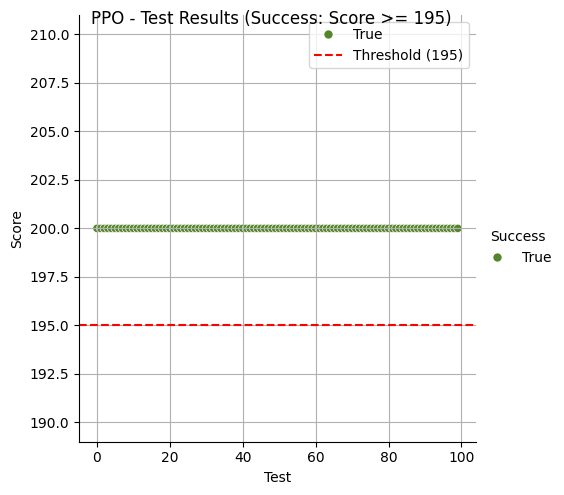

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to test the PPO agent
def test_ppo_agent(policy, i, print_reward=False):
    # Create a test environment
    env = gym.make('CartPole-v0')
    env.seed(i)
    state = env.reset()
    total_reward = 0

    for t in range(200):  # Fixed max steps for testing
        # Get action probabilities from the trained policy
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        action_probs, _ = policy(state_tensor)
        action = torch.argmax(action_probs).item()  # Select the action with the highest probability
        state, reward, done, _ = env.step(action)
        total_reward += reward
        if done:
            break

    env.close()
    if print_reward:
        print(f"Reward: {total_reward}")
    return total_reward

# Function to plot test results
def plot_test_results(method='', total=100):
    test_scores = []
    for i in range(total):
        test_scores.append(test_ppo_agent(policy, i, print_reward=False))

    print(f"Test scores: {test_scores}")

    # Define success as achieving a score >= 195
    colors = {True: "#54852A", False: "#E33079"}
    test_df = pd.DataFrame({'Test': range(total), 'Score': test_scores})
    test_df['Success'] = test_df['Score'] >= 195

    # Print statistics
    print(test_df['Score'].describe())
    success_count = test_df['Success'].value_counts()
    print(success_count)

    # Plot results
    ax = sns.relplot(data=test_df, x="Test", y="Score", hue="Success", palette=colors)
    ax.fig.suptitle(f"{method} - Test Results (Success: Score >= 195)")
    plt.axhline(y=195, color='r', linestyle='--', label='Threshold (195)')
    plt.legend()
    plt.grid()
    plt.show()

# Test and plot results
plot_test_results(method='PPO', total=100)


In [ ]:
!pip install SumTree

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 4.3 MB/s eta 0:00:00
